# **Macroeconomic Credit Spread Forecasting with Scenario Analysis and Investment Applications**

# Table of Contents

1. [Project Overview](#1-project-overview)
2. [Import Libraries](#2-import-libraries)
3. [Data Wrangling](#3-data-wrangling)
   - [3.1 Data Loading](#31-data-loading)
   - [3.2 Data Inspection and Cleaning](#32-data-inspection-and-cleaning)
   - [3.3 Data Transformation, Frequency Alignment, and Integration](#33-data-transformation-frequency-alignment-and-integration)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis-eda)
   - [4.1 Descriptive Analysis](#41-descriptive-analysis)
   - [4.2 Time-Series Analysis](#42-time-series-analysis)
   - [4.3 Correlation Analysis](#43-correlation-analysis)
   - [4.4 Lagged Relationships](#44-lagged-relationships)

5. [Feature Engineering](#5-feature-engineering)

## **1. Project Overview**

Credit spreads reflect the additional yield investors demand for holding corporate debt relative to lower-risk U.S. Treasury securities. Changes in credit spreads can provide information about market expectations, economic conditions, and perceived corporate credit risk.

This project examines the relationship between macroeconomic conditions and U.S. corporate credit spreads. The analysis will explore whether variables such as interest rates, inflation, unemployment, and the Treasury yield curve can help explain and predict changes in credit spreads.

The project will combine time-series analysis, predictive modeling, and scenario analysis to evaluate how credit markets respond to changing macroeconomic conditions.

## **2. Import Libraries**

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series Analysis
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Model Selection & Hyperparameter Tuning
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Utilities
import warnings
warnings.filterwarnings("ignore")


##  **3. Data Wrangling**

This section prepares the raw financial and macroeconomic data for analysis and modeling. The data wrangling process includes loading and inspecting the datasets, cleaning and transforming variables, aligning datasets with different frequencies, and merging them into a single time-series dataset.



### **3.1 Data Loading**

This section imports the datasets used throughout the project. The primary target variable is the Moody’s Seasoned Baa Corporate Bond Yield Relative to the 10-Year Treasury Yield, which measures the yield spread between Baa-rated corporate bonds and 10-year U.S. Treasury securities.

The analysis also incorporates macroeconomic and financial market predictors obtained primarily from the Federal Reserve Economic Data (FRED) database. These include the unemployment rate, Consumer Price Index (CPI), federal funds rate, 10-year Treasury yield, real GDP, and VIX volatility index. The datasets will later be cleaned, transformed where necessary, and aligned to a common monthly frequency before being merged into a single time-series dataset for analysis and forecasting.

In [2]:
!pip install pandas-datareader

In [3]:
from pandas_datareader import data as web
import datetime as dt

In [4]:
# Load target variable: Moody's Baa corporate credit spread

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=BAA10YM"

credit_spread = pd.read_csv(url)

credit_spread.head()

,observation_date,BAA10YM
0,1953-04-01,0.82
1,1953-05-01,0.73
2,1953-06-01,0.75
3,1953-07-01,0.93
4,1953-08-01,0.90


In [5]:
credit_spread = credit_spread.rename(
    columns={
        "observation_date": "date",
        "BAA10YM": "credit_spread"
    }
)

credit_spread["date"] = pd.to_datetime(credit_spread["date"])

credit_spread.head()

,date,credit_spread
0,1953-04-01,0.82
1,1953-05-01,0.73
2,1953-06-01,0.75
3,1953-07-01,0.93
4,1953-08-01,0.90


In [6]:
# Load macroeconomic predictor: U.S. unemployment rate
unemployment_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE"

unemployment = pd.read_csv(unemployment_url)

unemployment.head()

,observation_date,UNRATE
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5


In [7]:
# Load macroeconomic predictor: Consumer Price Index (CPI)

cpi_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"

cpi = pd.read_csv(cpi_url)

cpi.head()

,observation_date,CPIAUCSL
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.00
3,1947-04-01,22.00
4,1947-05-01,21.95


In [8]:
# Load macroeconomic predictor: Federal Funds Rate

fed_funds_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=FEDFUNDS"

fed_funds = pd.read_csv(fed_funds_url)

fed_funds.head()

,observation_date,FEDFUNDS
0,1954-07-01,0.80
1,1954-08-01,1.22
2,1954-09-01,1.07
3,1954-10-01,0.85
4,1954-11-01,0.83


In [9]:
# Load macroeconomic predictor: 10-Year Treasury Yield

treasury_10y_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=GS10"

treasury_10y = pd.read_csv(treasury_10y_url)

treasury_10y.head()

,observation_date,GS10
0,1953-04-01,2.83
1,1953-05-01,3.05
2,1953-06-01,3.11
3,1953-07-01,2.93
4,1953-08-01,2.95


In [10]:
# Load macroeconomic predictor: Real Gross Domestic Product (GDP)

gdp_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=GDPC1"

gdp = pd.read_csv(gdp_url)

gdp.head()

,observation_date,GDPC1
0,1947-01-01,2182.681
1,1947-04-01,2176.892
2,1947-07-01,2172.432
3,1947-10-01,2206.452
4,1948-01-01,2239.682


In [11]:
# Load market risk predictor: VIX Volatility Index

vix_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=VIXCLS"

vix = pd.read_csv(vix_url)

vix.head()

,observation_date,VIXCLS
0,1990-01-02,17.24
1,1990-01-03,18.19
2,1990-01-04,19.22
3,1990-01-05,20.11
4,1990-01-08,20.26


### **3.2 Data Inspection and Cleaning**

Before merging the datasets, each variable is inspected for its structure, data types, date coverage, missing values, and potential data quality issues. Necessary cleaning steps are then applied to ensure consistency across datasets.

In [12]:
# Inspect target variable structure
credit_spread.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           880 non-null    datetime64[ns]
 1   credit_spread  880 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 13.9 KB


In [13]:
credit_spread.shape

(880, 2)

In [14]:
credit_spread["date"].min(), credit_spread["date"].max()

(Timestamp('1953-04-01 00:00:00'), Timestamp('2026-07-01 00:00:00'))

In [15]:
# Check for missing values
credit_spread.isnull().sum()

,0
date,0
credit_spread,0


In [16]:
# Check for duplicate rows
credit_spread.duplicated().sum()

np.int64(0)


**The Credit Spread dataset** contains no missing or duplicate observations, and both columns have appropriate data types. The dataset contains 880 monthly observations spanning from April 1953 to July 2026

In [17]:
# Inspect unemployment dataset
unemployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  943 non-null    object 
 1   UNRATE            942 non-null    float64
dtypes: float64(1), object(1)
memory usage: 14.9+ KB


In [18]:
unemployment.shape

(943, 2)

In [19]:
unemployment["observation_date"].min(), unemployment["observation_date"].max()

('1948-01-01', '2026-07-01')

In [20]:
# Rename columns for consistency
unemployment = unemployment.rename(
    columns={
        "observation_date": "date",
        "UNRATE": "unemployment_rate"
    }
)

In [21]:
# Convert date column to datetime
unemployment["date"] = pd.to_datetime(unemployment["date"])

In [22]:
# Identify missing values
unemployment[unemployment["unemployment_rate"].isna()]

,date,unemployment_rate
933,2025-10-01,NaN


**The Unemployment dataset** contains 943 **monthly** observations spanning from January 1948 to July 2026. The date column was converted to datetime and columns were renamed for consistency. One missing unemployment-rate observation occurs in October 2025 because household survey data were not collected during the 2025 federal government shutdown. The missing value is retained at this stage and will be addressed during dataset alignment and preprocessing.

In [23]:
# Inspect CPI dataset

cpi.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 955 entries, 0 to 954
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  955 non-null    object 
 1   CPIAUCSL          954 non-null    float64
dtypes: float64(1), object(1)
memory usage: 15.1+ KB


In [24]:
cpi.shape

(955, 2)

In [25]:
cpi["observation_date"].min(), cpi["observation_date"].max()

('1947-01-01', '2026-07-01')

In [26]:
# Rename columns for consistency
cpi =  cpi.rename(
    columns={
        "observation_date": "date",
        "CPIAUCSL": "cpi"
    }
)

In [27]:
# Convert date column to datetime
cpi["date"] = pd.to_datetime( cpi["date"])

In [28]:
# Check for missing values

cpi[cpi["cpi"].isna()]


,date,cpi
945,2025-10-01,NaN


In [29]:
# Check for duplicate observations

cpi.duplicated().sum()

np.int64(0)

**The CPI dataset** contains 955 **monthly** observations spanning from January 1947 to July 2026. The date column was converted to datetime and columns were renamed for consistency. One observation is missing for October 2025 (government shutdown). The missing value will be addressed during preprocessing and frequency alignment.

In [30]:
# Inspect Federal Funds Rate dataset

fed_funds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 865 entries, 0 to 864
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  865 non-null    object 
 1   FEDFUNDS          865 non-null    float64
dtypes: float64(1), object(1)
memory usage: 13.6+ KB


In [31]:
fed_funds.shape

(865, 2)

In [32]:
fed_funds["observation_date"].min(), fed_funds["observation_date"].max()

('1954-07-01', '2026-07-01')

In [33]:
# Rename columns for consistency
fed_funds = fed_funds.rename(
    columns={
        "observation_date": "date",
        "FEDFUNDS": "fed_funds_rate"
    }
)

In [34]:
# Convert date column to datetime
fed_funds["date"] = pd.to_datetime( fed_funds["date"])

In [35]:
# Check for missing values
fed_funds[fed_funds["fed_funds_rate"].isna()]

,date,fed_funds_rate


In [36]:
# Check for duplicate observations
fed_funds.duplicated().sum()

np.int64(0)

**The Federal Funds Rate dataset** contains 865 **monthly** observations spanning from July 1954 to July 2026. The columns were renamed for consistency, and the date column was converted to datetime format. The dataset contains no missing values or duplicate observations.

In [37]:
# Inspect 10-Year Treasury Yield dataset
treasury_10y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  880 non-null    object 
 1   GS10              880 non-null    float64
dtypes: float64(1), object(1)
memory usage: 13.9+ KB


In [38]:
treasury_10y.shape

(880, 2)

In [39]:
treasury_10y["observation_date"].min(), treasury_10y["observation_date"].max()

('1953-04-01', '2026-07-01')

In [40]:
# Rename columns for consistency
treasury_10y = treasury_10y.rename(
    columns={
        "observation_date": "date",
        "GS10": "treasury_10y"
    }
)

# Convert date column to datetime
treasury_10y["date"] = pd.to_datetime(treasury_10y["date"])

In [41]:
# Check for missing values
treasury_10y[treasury_10y["treasury_10y"].isna()]

,date,treasury_10y


In [42]:
treasury_10y.duplicated().sum()

np.int64(0)

**The 10-Year Treasury Yield dataset** contains 880 **monthly** observations spanning from April 1953 to July 2026. The columns were renamed for consistency, and the date column was converted to datetime format. The dataset contains no missing values or duplicate observations.

In [43]:
# Inspect Real GDP dataset
gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318 entries, 0 to 317
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  318 non-null    object 
 1   GDPC1             318 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.1+ KB


In [44]:
gdp.shape

(318, 2)

In [45]:
gdp.head()

,observation_date,GDPC1
0,1947-01-01,2182.681
1,1947-04-01,2176.892
2,1947-07-01,2172.432
3,1947-10-01,2206.452
4,1948-01-01,2239.682


In [46]:
gdp["observation_date"].min(), gdp["observation_date"].max()

('1947-01-01', '2026-04-01')

In [47]:
# Rename columns for consistency
gdp = gdp.rename(
    columns={
        "observation_date": "date",
        "GDPC1": "real_gdp"
    }
)

# Convert date column to datetime
gdp["date"] = pd.to_datetime(gdp["date"])

In [48]:
# Check for missing values
gdp[gdp["real_gdp"].isna()]

,date,real_gdp


In [49]:
# Check for duplicate observations
gdp.duplicated().sum()

np.int64(0)

**The Real GDP dataset** contains 318 **quarterly** observations spanning from January 1947 to April 2026. The columns were renamed for consistency, and the date column was converted to datetime format. The dataset contains no missing values or duplicate observations.

In [50]:
# Inspect VIX dataset
vix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9553 entries, 0 to 9552
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  9553 non-null   object 
 1   VIXCLS            9251 non-null   float64
dtypes: float64(1), object(1)
memory usage: 149.4+ KB


In [51]:
vix.shape

(9553, 2)

In [52]:
vix.head()

,observation_date,VIXCLS
0,1990-01-02,17.24
1,1990-01-03,18.19
2,1990-01-04,19.22
3,1990-01-05,20.11
4,1990-01-08,20.26


In [53]:
# Rename columns for consistency
vix = vix.rename(
    columns={
        "observation_date": "date",
        "VIXCLS": "vix"
    }
)

# Convert date column to datetime
vix["date"] = pd.to_datetime(vix["date"])

In [54]:
# Identify missing VIX observations
vix[vix["vix"].isna()]

,date,vix
34,1990-02-19,NaN
73,1990-04-13,NaN
104,1990-05-28,NaN
131,1990-07-04,NaN
174,1990-09-03,NaN
...,...,...
9131,2025-01-01,NaN
9208,2025-04-18,NaN
9387,2025-12-25,NaN
9392,2026-01-01,NaN


In [55]:
vix.duplicated().sum()

np.int64(0)

**The VIX (CBOE Volatility Index)** measures the market’s expectation of near-term volatility based on S&P 500 options. It is commonly used as an indicator of market uncertainty and investor risk sentiment.
**The VIX dataset** contains **daily** observations beginning in January 1990. The columns were renamed for consistency, and the date column was converted to datetime format. The dataset contains 302 missing observations, which are retained at this stage and will be addressed when the daily series is aggregated to monthly frequency.

### **3.3 Data Transformation, Frequency Alignment, and Integration**

The datasets contain variables reported at different frequencies and in different forms. In this section, CPI is transformed into a year-over-year inflation rate, Real GDP is transformed into a GDP growth measure, quarterly GDP data are appropriately aligned with the monthly dataset, and daily VIX observations are aggregated to monthly frequency. The datasets are then restricted to a common time period beginning in 1990 and merged into a single monthly dataset for further analysis and modeling

#### **CPI to Year-over-Year Inflation**
The CPI series represents the price index level rather than the inflation rate itself. To create a more economically meaningful predictor, year-over-year inflation is calculated as the percentage change in CPI relative to the same month of the previous year. This transformation captures the annual rate of change in consumer prices while accounting for the monthly frequency of the data.

In [56]:
# Calculate year-over-year inflation rate from CPI
cpi["inflation_yoy"] = cpi["cpi"].pct_change(periods=12) * 100

In [57]:
# Inspect the transformed CPI data
cpi.head(15)

,date,cpi,inflation_yoy
0,1947-01-01,21.48,NaN
1,1947-02-01,21.62,NaN
2,1947-03-01,22.00,NaN
3,1947-04-01,22.00,NaN
4,1947-05-01,21.95,NaN
5,1947-06-01,22.08,NaN
6,1947-07-01,22.23,NaN
7,1947-08-01,22.40,NaN
8,1947-09-01,22.84,NaN
9,1947-10-01,22.91,NaN


The first 12 observations of the year-over-year inflation rate are missing because a full 12 months of prior CPI data are required to calculate the annual percentage change.

#### **Real GDP to Year-over-Year Growth**

Real GDP is reported as the level of inflation-adjusted economic output. To create a more meaningful measure of economic activity, year-over-year GDP growth is calculated as the percentage change in Real GDP relative to the same quarter of the previous year. Since Real GDP is reported quarterly, a four-quarter percentage change is used.

In [58]:
# Calculate year-over-year Real GDP growth
gdp["gdp_growth_yoy"] = gdp["real_gdp"].pct_change(periods=4) * 100

# Inspect the transformed Real GDP data
gdp.head(8)

,date,real_gdp,gdp_growth_yoy
0,1947-01-01,2182.681,NaN
1,1947-04-01,2176.892,NaN
2,1947-07-01,2172.432,NaN
3,1947-10-01,2206.452,NaN
4,1948-01-01,2239.682,2.611513
5,1948-04-01,2276.690,4.584426
6,1948-07-01,2289.770,5.401228
7,1948-10-01,2292.364,3.893672


The first four observations of the year-over-year GDP growth rate are missing because four quarters of prior Real GDP data are required to calculate the annual percentage change.

#### **Real GDP Quarterly-to-Monthly Alignment**

Real GDP is reported quarterly, while the remaining variables are aligned at a monthly frequency. To ensure consistency before merging, quarterly GDP growth is converted to monthly frequency by assigning each quarterly observation to the three months within its corresponding quarter using forward filling. This alignment is appropriate for descriptive macroeconomic analysis. **For forecasting, GDP release timing will be addressed separately to avoid look-ahead bias, since realized GDP is released after the quarter it represents.**

In [59]:
gdp_monthly = (
    gdp.set_index("date")[["gdp_growth_yoy"]]
       .resample('MS')
       .ffill()
       .reset_index()
)

gdp_monthly.head(24)

,date,gdp_growth_yoy
0,1947-01-01,NaN
1,1947-02-01,NaN
2,1947-03-01,NaN
3,1947-04-01,NaN
4,1947-05-01,NaN
5,1947-06-01,NaN
6,1947-07-01,NaN
7,1947-08-01,NaN
8,1947-09-01,NaN
9,1947-10-01,NaN


#### **VIX Daily-to-Monthly Aggregation**

The VIX is reported at a daily frequency, while the target credit spread and most macroeconomic predictors are monthly. To ensure consistent frequency across the dataset, daily VIX observations are aggregated to monthly frequency using the mean. The monthly average is used to capture the overall level of market volatility during each month while reducing short-term daily fluctuations.

In [60]:
# Create a new vix_monthly dataset
vix_monthly = (
    vix.set_index("date")
       .resample("MS")["vix"]
       .mean()
       .reset_index()
)
vix_monthly = vix_monthly.rename(columns={"vix": "vix_monthly"})

In [61]:
vix_monthly.head()

,date,vix_monthly
0,1990-01-01,23.347273
1,1990-02-01,23.262632
2,1990-03-01,20.062273
3,1990-04-01,21.403500
4,1990-05-01,18.097727


Before merging the monthly datasets, the date columns are checked to confirm that observations use a consistent monthly date convention. All monthly series are labeled on the first day of the month, ensuring that they can be aligned correctly during the merge.

In [62]:
print(cpi["date"].dt.day.unique())
print(unemployment["date"].dt.day.unique())
print(fed_funds["date"].dt.day.unique())
print(treasury_10y["date"].dt.day.unique())
print(gdp_monthly["date"].dt.day.unique())
print(vix_monthly["date"].dt.day.unique())

[1]
[1]
[1]
[1]
[1]
[1]


CPI, Unemployment, Fed Funds, and 10-year Treasury are all consistently labeled at the beginning of the month.

#### **Dataset Integration**

After transforming the variables and aligning them to a common monthly frequency, the individual datasets are merged into a single dataset using the date column as the common key. The credit spread dataset serves as the base dataset, and the macroeconomic variables are added via left joins. This method preserves the full credit spread timeline while letting you identify and address missing observations caused by differences in data availability after the merge.

In [63]:
# Assign credit spread target as the base dataset
data = credit_spread.copy()

# Merge macroeconomic predictors by date
data = data.merge(cpi[['date', 'inflation_yoy']], on='date', how='left')
data = data.merge(unemployment, on='date', how='left')
data = data.merge(fed_funds, on='date', how='left')
data = data.merge(treasury_10y, on='date', how='left')
data = data.merge(gdp_monthly[['date', 'gdp_growth_yoy']], on='date', how='left')
data = data.merge(vix_monthly, on='date', how='left')

In [64]:
data.head()

,date,credit_spread,inflation_yoy,unemployment_rate,fed_funds_rate,treasury_10y,gdp_growth_yoy,vix_monthly
0,1953-04-01,0.82,0.869237,2.7,NaN,2.83,6.781988,NaN
1,1953-05-01,0.73,0.868908,2.5,NaN,3.05,6.781988,NaN
2,1953-06-01,0.75,0.904636,2.5,NaN,3.11,6.781988,NaN
3,1953-07-01,0.93,0.412294,2.6,NaN,2.93,5.420994,NaN
4,1953-08-01,0.90,0.599475,2.7,NaN,2.95,5.420994,NaN


In [65]:
data.shape

(880, 8)

In [66]:
# Restrict dataset to the common analysis period beginning in 1990
data = data[data['date'] >= '1990-01-01'].reset_index(drop=True)

In [67]:
data.head()

,date,credit_spread,inflation_yoy,unemployment_rate,fed_funds_rate,treasury_10y,gdp_growth_yoy,vix_monthly
0,1990-01-01,1.73,5.198020,5.4,8.23,8.21,2.821007,23.347273
1,1990-02-01,1.67,5.263158,5.3,8.24,8.47,2.821007,23.262632
2,1990-03-01,1.62,5.237316,5.2,8.28,8.59,2.821007,20.062273
3,1990-04-01,1.51,4.711617,5.4,8.26,8.79,2.412705,21.403500
4,1990-05-01,1.65,4.365400,5.4,8.18,8.76,2.412705,18.097727


In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               439 non-null    datetime64[ns]
 1   credit_spread      439 non-null    float64       
 2   inflation_yoy      439 non-null    float64       
 3   unemployment_rate  438 non-null    float64       
 4   fed_funds_rate     439 non-null    float64       
 5   treasury_10y       439 non-null    float64       
 6   gdp_growth_yoy     436 non-null    float64       
 7   vix_monthly        439 non-null    float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 27.6 KB


In [69]:
# Checking the missing values in 'gdp_growth_yoy'

data[data['gdp_growth_yoy'].isna()]

,date,credit_spread,inflation_yoy,unemployment_rate,fed_funds_rate,treasury_10y,gdp_growth_yoy,vix_monthly
436,2026-05-01,1.62,4.166615,4.3,3.63,4.48,NaN,17.237143
437,2026-06-01,1.53,3.463531,4.2,3.63,4.47,NaN,17.906818
438,2026-07-01,1.59,3.303856,4.1,3.63,4.60,NaN,17.090870


In [70]:
# The last quarter didn't get a forward fill previously. Applying the April
# value to May and June and leaving July off for now

april_gdp = data.loc[data['date'] == '2026-04-01', 'gdp_growth_yoy'].iloc[0]

data.loc[data['date'] == '2026-05-01', 'gdp_growth_yoy'] = april_gdp
data.loc[data['date'] == '2026-06-01', 'gdp_growth_yoy'] = april_gdp

In [71]:
data[data['gdp_growth_yoy'].isna()]

,date,credit_spread,inflation_yoy,unemployment_rate,fed_funds_rate,treasury_10y,gdp_growth_yoy,vix_monthly
438,2026-07-01,1.59,3.303856,4.1,3.63,4.6,NaN,17.09087


In [72]:
data[data['unemployment_rate'].isna()]

,date,credit_spread,inflation_yoy,unemployment_rate,fed_funds_rate,treasury_10y,gdp_growth_yoy,vix_monthly
429,2025-10-01,1.68,2.729136,NaN,4.09,4.06,1.9893,18.086522


In [73]:
cpi[(cpi['date'] >= '2025-08-01') & (cpi['date'] <= '2025-12-01')]

,date,cpi,inflation_yoy
943,2025-08-01,323.291,2.938592
944,2025-09-01,324.245,3.022572
945,2025-10-01,NaN,2.729136
946,2025-11-01,325.063,2.696444
947,2025-12-01,326.031,2.653304


In [74]:
data.loc[data['date'] == '2025-10-01', 'inflation_yoy'] = np.nan

In [75]:
# Remaining missing values:
# October 2025: CPI and unemployment data were unavailable, so inflation_yoy
# and unemployment_rate are left as NaN for later imputation.
# July 2026: gdp_growth_yoy is unavailable because Q3 GDP has not yet been observed.

data[data.isna().any(axis=1)]

,date,credit_spread,inflation_yoy,unemployment_rate,fed_funds_rate,treasury_10y,gdp_growth_yoy,vix_monthly
429,2025-10-01,1.68,NaN,NaN,4.09,4.06,1.9893,18.086522
438,2026-07-01,1.59,3.303856,4.1,3.63,4.60,NaN,17.090870


## **4. Exploratory Data Analysis (EDA)**

### **4.1 Descriptive Analysis**



In [76]:
data.drop(columns = "date").describe().T

,count,mean,std,min,25%,50%,75%,max
credit_spread,439.0,2.281936,0.709612,1.290000,1.740000,2.140000,2.680000,6.010000
inflation_yoy,438.0,2.710159,1.587745,-1.958761,1.737717,2.613670,3.250138,8.979361
unemployment_rate,438.0,5.654795,1.736738,3.400000,4.300000,5.300000,6.575000,14.800000
fed_funds_rate,439.0,2.891321,2.326328,0.050000,0.335000,2.960000,5.220000,8.290000
treasury_10y,439.0,4.252323,1.922750,0.620000,2.635000,4.180000,5.695000,8.890000
gdp_growth_yoy,438.0,2.499437,1.980006,-7.398615,1.800754,2.604510,3.430707,12.385669
vix_monthly,439.0,19.452968,7.366569,10.125455,14.150844,17.683182,22.916807,62.668947


The descriptive statistics show substantial variation in both the credit spread and macroeconomic indicators over the sample period. Credit spreads average approximately 2.28 percentage points, with values ranging from 1.29 to 6.01, indicating periods of significant spread widening. Several macroeconomic variables also exhibit extreme observations, particularly unemployment, GDP growth, and the VIX, reflecting periods of economic and financial stress. The VIX shows especially pronounced variation, with a maximum substantially above its median and upper quartile. Overall, the ranges indicate that the dataset captures a variety of economic conditions, including periods of recession, market stress, high inflation, and changing interest-rate environments.

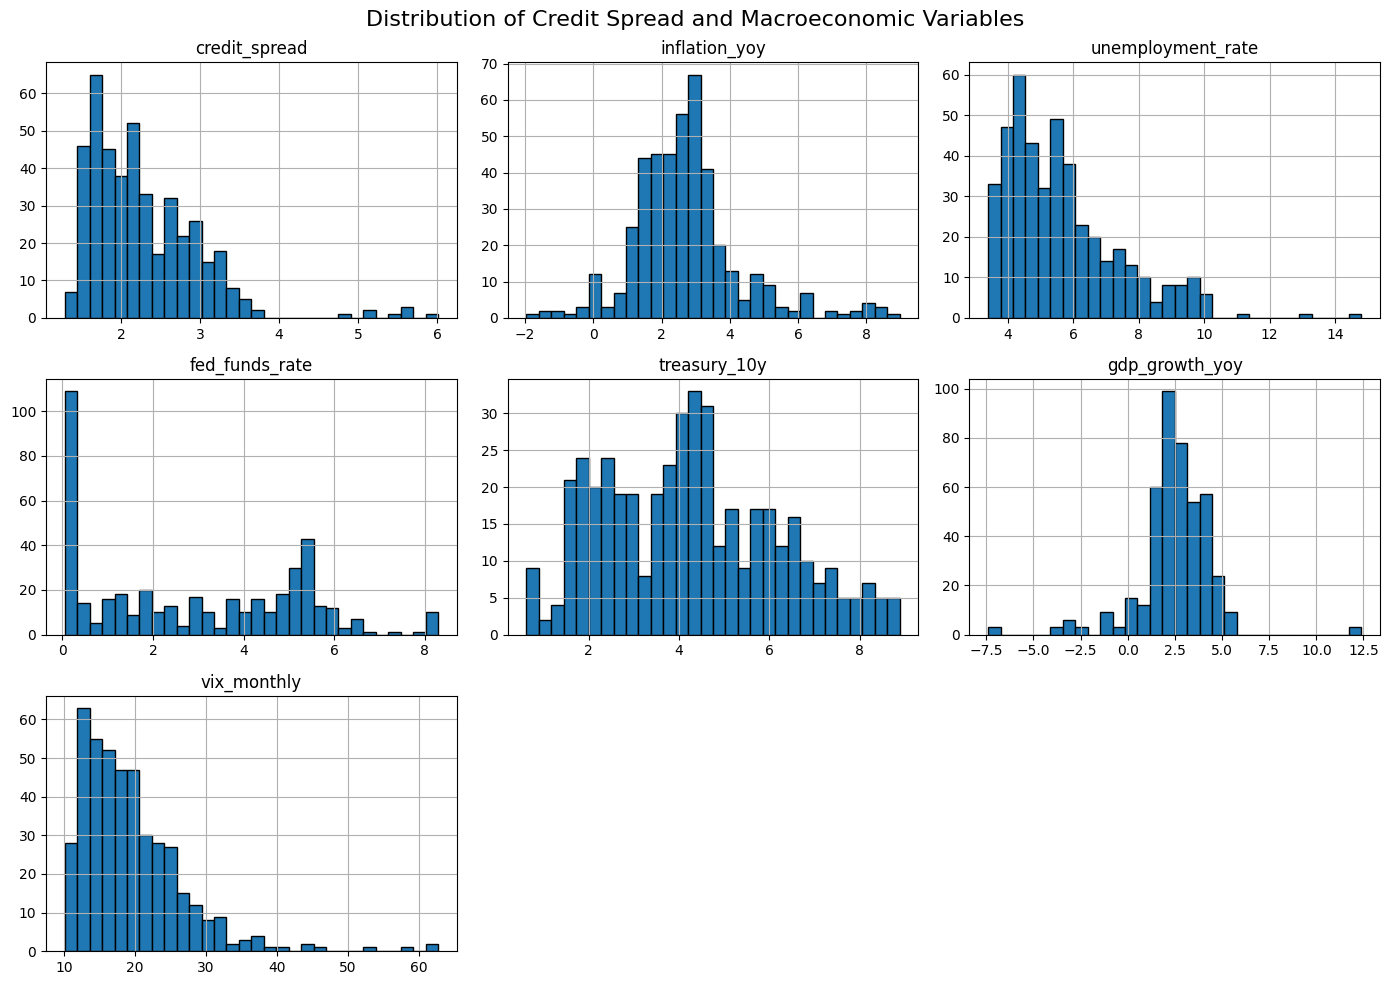

In [77]:
# Plot distributions of the credit spread and macroeconomic variables

columns = [
    "credit_spread",
    "inflation_yoy",
    "unemployment_rate",
    "fed_funds_rate",
    "treasury_10y",
    "gdp_growth_yoy",
    "vix_monthly"
]

data[columns].hist(
    bins=30,
    figsize=(14, 10),
    edgecolor="black"
)

plt.suptitle("Distribution of Credit Spread and Macroeconomic Variables", fontsize=16)
plt.tight_layout()
plt.show()

The histograms provide a clearer view of how the observations are distributed across each variable. Inflation and GDP growth are relatively concentrated around their typical historical levels, with inflation largely centered around 2–3% and GDP growth around 2–4%. GDP growth also contains several extreme observations, ranging from approximately −7.4% to 12.4%, reflecting periods of unusually sharp economic contraction and expansion. The VIX exhibits a pronounced right-skewed distribution, with most monthly observations concentrated at relatively low levels and a long right tail extending above 60 during periods of elevated market volatility. Credit spreads and unemployment also display right-skewed distributions, with relatively few observations at substantially higher levels. These distributions highlight the presence of extreme economic and financial conditions within the sample that may be particularly relevant for modeling changes in credit spreads.

### **4.2 Time-Series Analysis**

#### **Credit Spread Over Time**

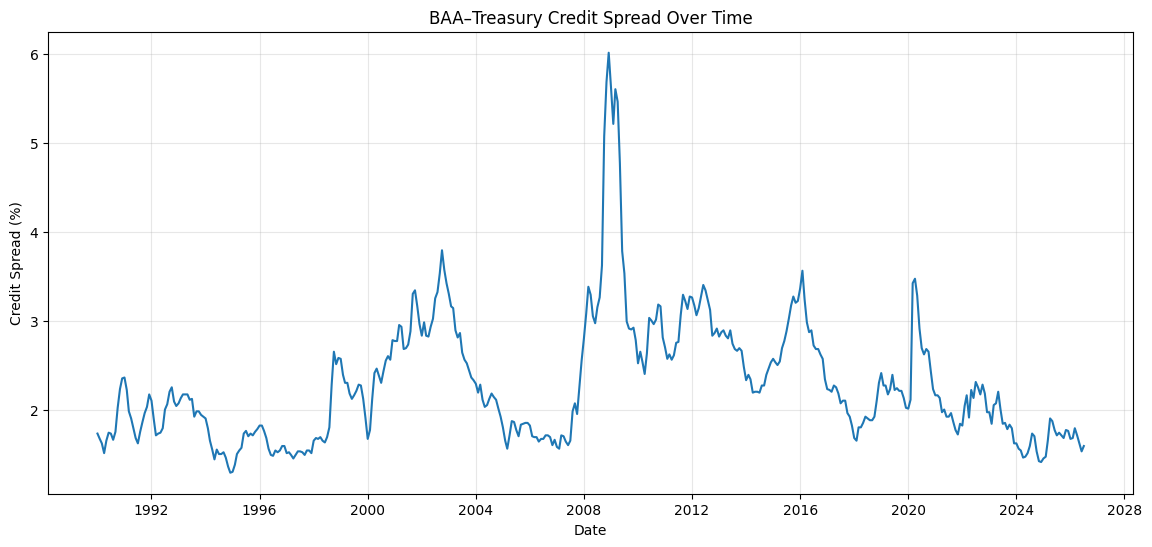

In [78]:
# Plot the credit spread over time

plt.figure(figsize=(14, 6))

plt.plot(data["date"], data["credit_spread"])

plt.title("BAA–Treasury Credit Spread Over Time")
plt.xlabel("Date")
plt.ylabel("Credit Spread (%)")
plt.grid(True, alpha=0.3)

plt.show()

The credit spread exhibits distinct periods of widening associated with economic and financial stress. Elevated spreads during 2000–2003 coincide with the dot-com downturn, the 2001 recession, and broader corporate credit concerns, while the most pronounced widening occurs during the 2008–2009 Global Financial Crisis. Another notable increase appears during 2015–2016 amid commodity-market and global growth concerns, despite the absence of a U.S. recession. A sharp but relatively short-lived widening is also visible during the 2020 COVID-19 shock. Overall, the series shows that credit spreads tend to remain relatively contained during stable periods but can widen rapidly when economic uncertainty and perceived credit risk increase.

#### **12-Month Rolling Mean**

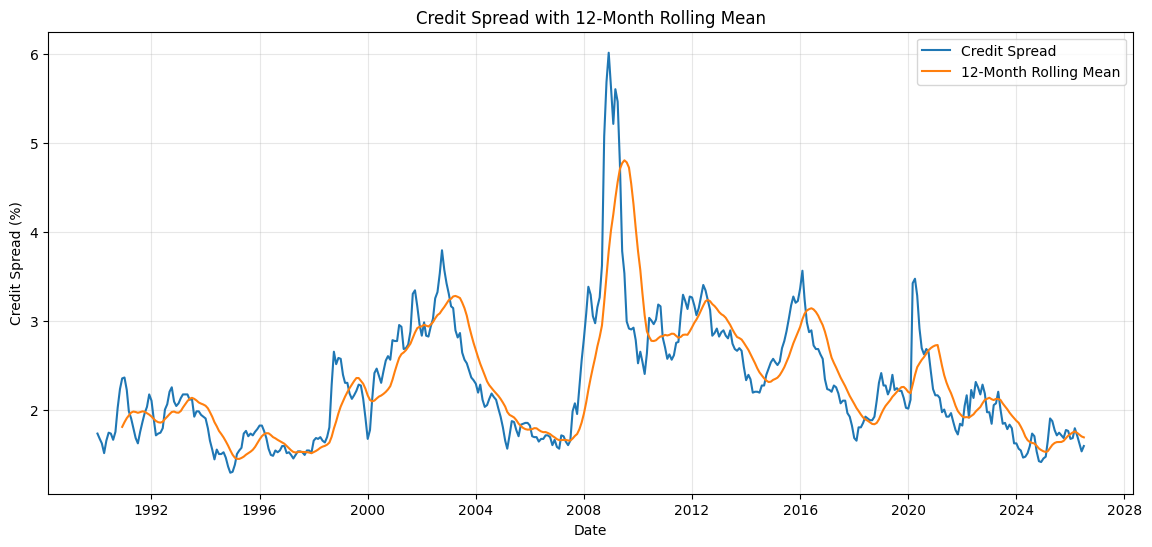

In [79]:
# Plot credit spread with 12-month rolling mean
rolling_mean = data["credit_spread"].rolling(window=12).mean()

plt.figure(figsize=(14, 6))

plt.plot(data["date"], data["credit_spread"], label="Credit Spread")
plt.plot(data["date"], rolling_mean, label="12-Month Rolling Mean")

plt.title("Credit Spread with 12-Month Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Credit Spread (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

The 12-month rolling mean smooths short-term fluctuations in the credit spread and highlights broader changes in its level over time. The prolonged increase around the 2008–2009 financial crisis indicates a sustained period of elevated credit stress, while the smaller increase around the 2020 COVID-19 shock reflects a sharper but more short-lived widening in spreads.

#### **12-Month Rolling Standard Deviation**

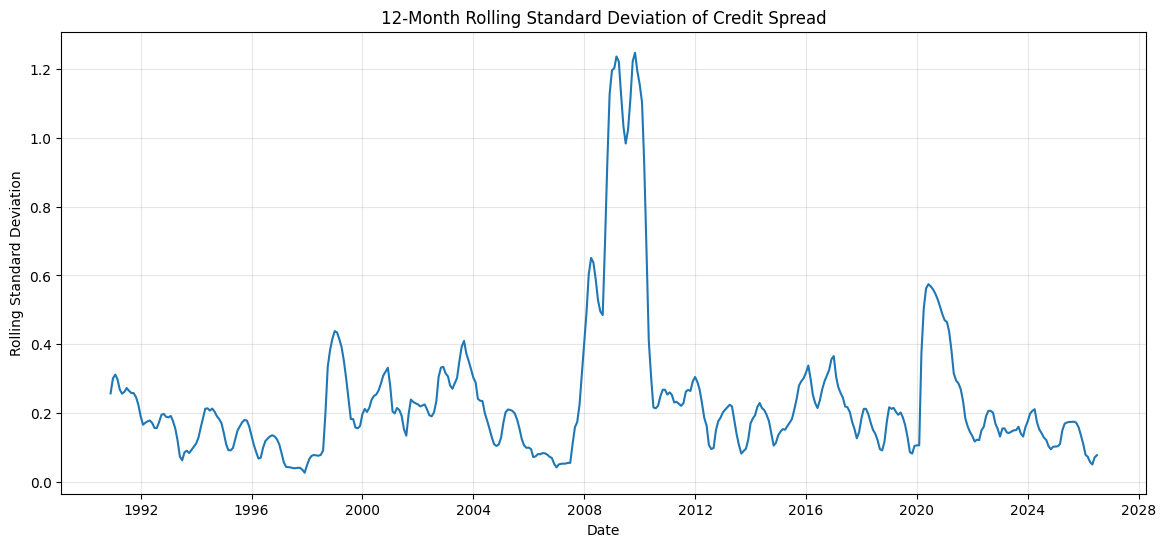

In [80]:
# Plot 12-month rolling standard deviation of the credit spread
rolling_std = data["credit_spread"].rolling(window=12).std()

plt.figure(figsize=(14, 6))

plt.plot(data["date"], rolling_std)

plt.title("12-Month Rolling Standard Deviation of Credit Spread")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.grid(True, alpha=0.3)

plt.show()

The 12-month rolling standard deviation shows that credit spread variability increases considerably during periods of financial and economic stress. A notable increase appears around 1998–1999, a period associated with the Russian debt default and the collapse of Long-Term Capital Management (LTCM). The Russian default triggered a global flight to safer and more liquid assets, causing many credit and relative-value spreads to widen sharply. This was particularly damaging to highly leveraged convergence strategies used by LTCM, which were positioned for certain pricing differences to narrow rather than widen.

Elevated variability is also visible during the early 2000s following the dot-com downturn and the 2001 recession. The most pronounced and sustained increase occurs during the 2008–2009 Global Financial Crisis, when credit-market uncertainty and liquidity stress intensified substantially. Smaller but noticeable increases appear around 2015–2017 amid commodity-market and global growth concerns and following the 2020 COVID-19 shock. Overall, the pattern suggests that credit spread volatility rises substantially during periods of heightened economic uncertainty, changing risk perceptions, and financial-market stress.

#### **Augmented Dickey-Fuller Test**

In [81]:
# Augmented Dickey-Fuller test for credit spread
adf_result = adfuller(data["credit_spread"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -3.8840309749487103
p-value: 0.002155564640150289
Critical Values:
   1%: -3.4454029241336483
   5%: -2.8681766097362087
   10%: -2.570305075326362


The Augmented Dickey-Fuller (ADF) test is used to test whether the credit spread contains a unit root and is therefore non-stationary.

- **Null hypothesis (H₀):** The credit spread has a unit root and is non-stationary.
- **Alternative hypothesis (H₁):** The credit spread does not have a unit root and is stationary.

The test produces an ADF statistic of −3.884 and a p-value of approximately 0.002. Since the p-value is below the 5% significance level, **the null hypothesis is rejected**. The ADF statistic is also more negative than the 1%, 5%, and 10% critical values, providing additional evidence against the presence of a unit root.

Therefore, **the credit spread is considered stationary** in the unit-root sense. This suggests that shocks to the level of the credit spread tend to dissipate over time rather than permanently shifting the series onto a new path. This behavior is consistent with the mean-reverting pattern observed in the time-series plot, where spreads widen sharply during periods of financial stress but eventually return toward more typical levels.

Although the ADF test provides evidence against a unit root, the rolling standard deviation indicates that the volatility of the credit spread is not constant over time and increases substantially during periods of market stress.

#### **ACF and PACF**

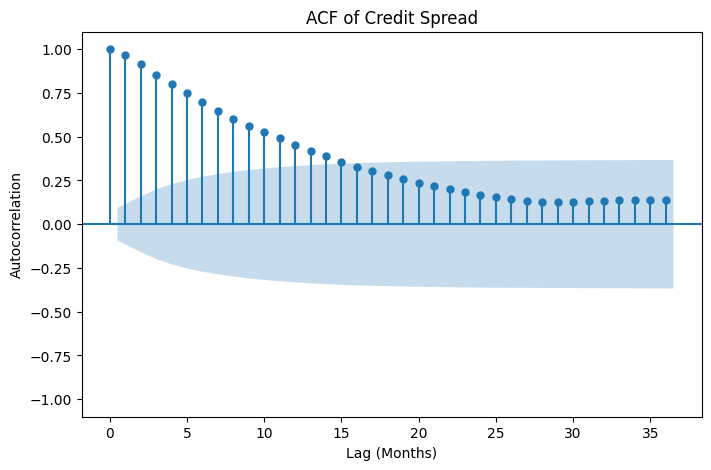

In [82]:
# Plot autocorrelation of the credit spread

fig, ax = plt.subplots(figsize=(8, 5))

plot_acf(
    data["credit_spread"].dropna(),
    lags=36,
    ax=ax
)

ax.set_title("ACF of Credit Spread")
ax.set_xlabel("Lag (Months)")
ax.set_ylabel("Autocorrelation")
ax.set_ylim(-1.1, 1.1)

plt.show()

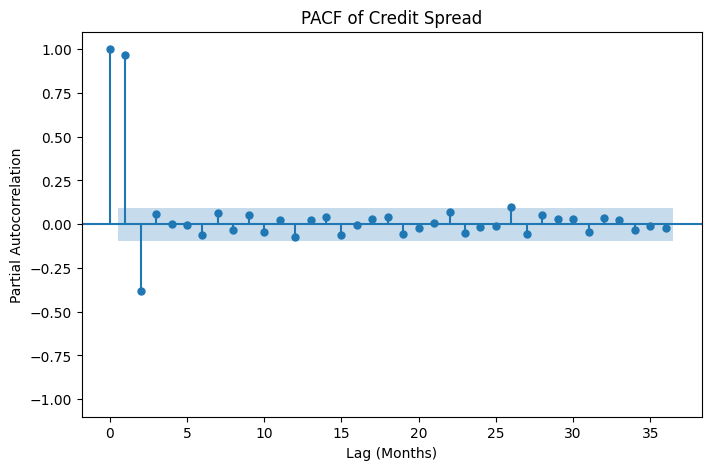

In [83]:
# Plot partial autocorrelation of the credit spread

fig, ax = plt.subplots(figsize=(8, 5))

plot_pacf(
    data["credit_spread"].dropna(),
    lags=36,
    method="ywm",
    ax=ax
)

ax.set_title("PACF of Credit Spread")
ax.set_xlabel("Lag (Months)")
ax.set_ylabel("Partial Autocorrelation")
ax.set_ylim(-1.1, 1.1)

plt.show()

The ACF shows strong positive autocorrelation across several lags, gradually declining as lag increases. This indicates persistence in credit spreads, where past values remain correlated with current levels over time.

The PACF isolates direct effects and shows a strong positive relationship at lag 1 and a negative one at lag 2, with most later lags being small. This suggests that the main direct dependence is concentrated in the first two lags.

Overall, while the ACF remains significant across many lags, this does not imply all should be included in a model. Much of the persistence is captured by early lags, making low-order AR models such as AR(1) or AR(2) reasonable starting points.

### **4.3 Correlation Analysis**

Correlation analysis is used to examine the strength and direction of the linear relationships between the credit spread and the macroeconomic variables, as well as relationships among the predictors themselves. This provides an initial indication of which variables may be associated with credit spread movements and helps identify potential multicollinearity among predictors.

In [84]:
# Correlation matrix

corr_matrix = data.drop(columns="date").corr()

corr_matrix

,credit_spread,inflation_yoy,unemployment_rate,fed_funds_rate,treasury_10y,gdp_growth_yoy,vix_monthly
credit_spread,1.000000,-0.376075,0.457742,-0.573407,-0.450863,-0.537344,0.630430
inflation_yoy,-0.376075,1.000000,-0.329600,0.353752,0.285135,0.234898,-0.027305
unemployment_rate,0.457742,-0.329600,1.000000,-0.446713,-0.114051,-0.453085,0.193649
fed_funds_rate,-0.573407,0.353752,-0.446713,1.000000,0.826935,0.209027,-0.092749
treasury_10y,-0.450863,0.285135,-0.114051,0.826935,1.000000,0.173930,-0.085665
gdp_growth_yoy,-0.537344,0.234898,-0.453085,0.209027,0.173930,1.000000,-0.384644
vix_monthly,0.630430,-0.027305,0.193649,-0.092749,-0.085665,-0.384644,1.000000


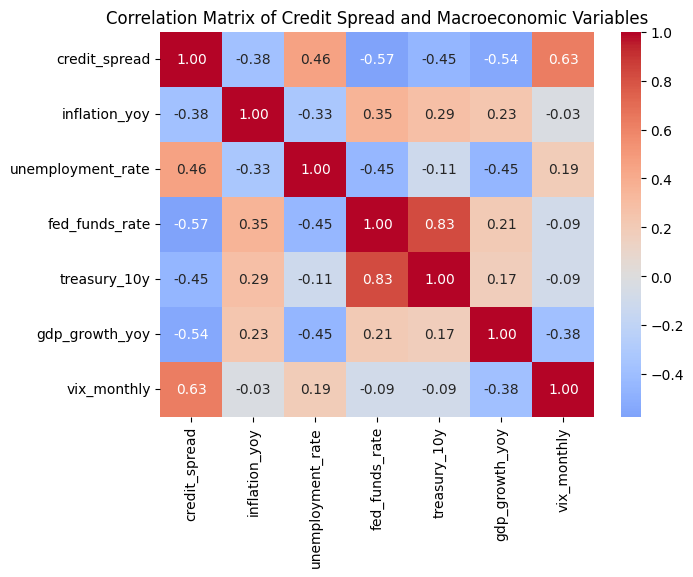

In [85]:
# Correlation heatmap

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Credit Spread and Macroeconomic Variables")
plt.show()

### **4.4 Lagged Relationships**

The correlation analysis above examines relationships between the credit spread and macroeconomic variables during the same period. However, changes in economic and market conditions may be associated with credit spreads over different time horizons. To explore these relationships, correlations between the current credit spread and past values of each predictor are examined at 1-, 3-, 6-, and 12-month lags, representing short-term, quarterly, semiannual, and annual horizons. The same-period correlation (lag 0) is also included as a reference. This analysis can help identify which variables and lag periods may contain useful information for forecasting future credit spreads.

In [86]:
# Lagged correlations between macroeconomic variables and credit spread

predictors = [
    "inflation_yoy",
    "unemployment_rate",
    "fed_funds_rate",
    "treasury_10y",
    "gdp_growth_yoy",
    "vix_monthly"
]

lags = [0, 1, 3, 6, 12]

lagged_corr = pd.DataFrame(index=predictors)

for lag in lags:
    lagged_corr[f"Lag {lag}"] = [
        data["credit_spread"].corr(data[var].shift(lag))
        for var in predictors
    ]

lagged_corr.round(2)

,Lag 0,Lag 1,Lag 3,Lag 6,Lag 12
inflation_yoy,-0.38,-0.33,-0.24,-0.16,-0.16
unemployment_rate,0.46,0.42,0.34,0.26,0.15
fed_funds_rate,-0.57,-0.55,-0.49,-0.41,-0.25
treasury_10y,-0.45,-0.43,-0.39,-0.33,-0.24
gdp_growth_yoy,-0.54,-0.51,-0.44,-0.33,-0.19
vix_monthly,0.63,0.64,0.56,0.44,0.28


The lagged correlation analysis shows that the relationship between most macroeconomic variables and the credit spread gradually weakens as the lag increases. This suggests that more recent economic and market conditions are more strongly associated with current credit spreads than observations further in the past. VIX maintains the strongest positive relationship across the shorter lag horizons, with its correlation remaining relatively strong through the 6-month lag. Overall, the results suggest that shorter lags may be more informative when constructing forecasting features.

**EDA Summary:** The exploratory analysis shows that credit spreads exhibit substantial persistence over time and tend to widen sharply during periods of economic and financial stress. The ADF test provides evidence that the credit spread is stationary, while the ACF and PACF indicate meaningful short-term autocorrelation that should be considered in time-series modeling. The correlation analysis identifies the strongest relationships with VIX (+0.63), the Federal Funds Rate (−0.57), and GDP growth (−0.54), followed by unemployment (+0.46) and the 10-Year Treasury yield (−0.45). Inflation shows a weaker relationship with the credit spread (−0.38). The high correlation between the Federal Funds Rate and 10-Year Treasury yield (+0.83) also indicates potential multicollinearity among predictors. Finally, the lagged analysis shows that these relationships generally weaken as the lag increases, suggesting that more recent macroeconomic and market information may be more useful for forecasting.